Rows: 17
Columns: ['Year', 'Incidents']
    Year  Incidents
65  1849         13
66  1850          6
67  1851         13
68  1852         18
69  1853         15

Incidents per year (from totals column):
Year
1849    13
1850     6
1851    13
1852    18
1853    15
1854    13
1855    26
1856    21
1857    42
1858    23
1859    24
1860    26
1861    17
1862     8
1863    21
1864    19
1865    15
Name: Incidents, dtype: int64


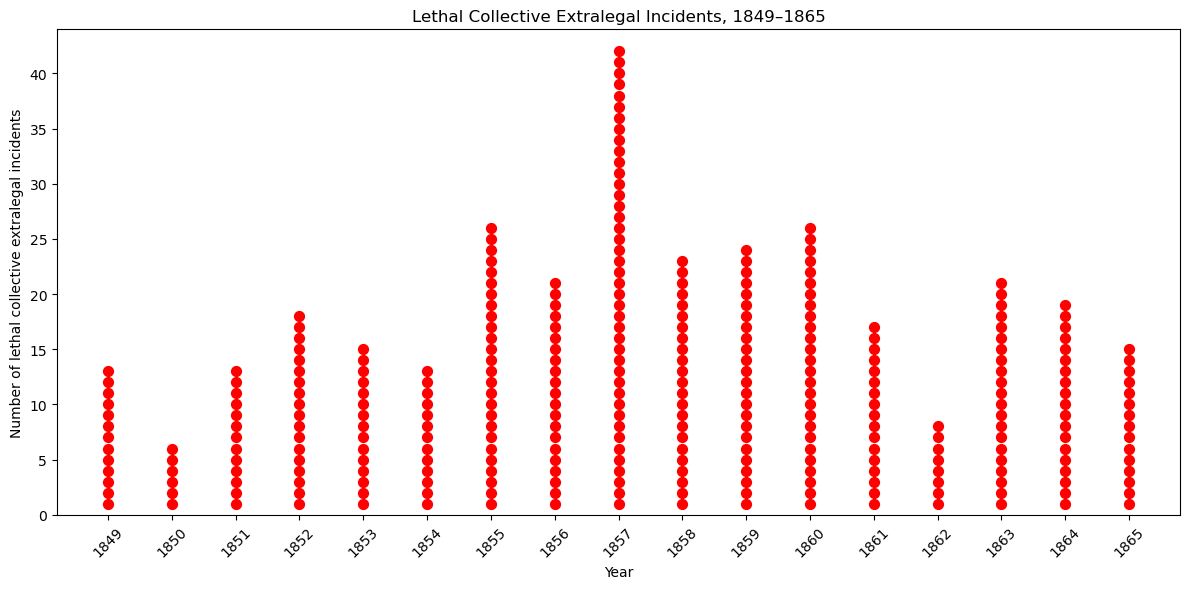

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Incidents_Year.csv")

# --- Make sure Year is numeric ---
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)

# --- Filter to match the figure range ---
df = df[(df["Year"] >= 1849) & (df["Year"] <= 1865)]

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print(df.head())

# --- Build stacked dot plot data (two possible CSV formats) ---
x, y = [], []

if "Incidents" in df.columns:
    # Case A: one row per year with totals in Incidents
    df["Incidents"] = pd.to_numeric(df["Incidents"], errors="coerce").fillna(0).astype(int)

    year_totals = df.groupby("Year")["Incidents"].sum()

    print("\nIncidents per year (from totals column):")
    print(year_totals)

    for year, total in year_totals.items():
        if total <= 0:
            continue
        x.extend([year] * total)
        y.extend(range(1, total + 1))

else:
    # Case B: one row per incident (event-level)
    year_counts = df.groupby("Year").size()

    print("\nIncidents per year (from event rows):")
    print(year_counts)

    for year, count in year_counts.items():
        x.extend([year] * count)
        y.extend(range(1, count + 1))

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.scatter(x, y, s=50, color="red")

plt.title("Lethal Collective Extralegal Incidents, 1849–1865")
plt.xlabel("Year")
plt.ylabel("Number of lethal collective extralegal incidents")

plt.xticks(range(1849, 1866, 1), rotation=45)
plt.ylim(0, max(y) + 2 if y else 5)

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the file path is correct
# Option 1: Place the CSV file in the same directory as your notebook
# Option 2: Provide the full path to the file
df = pd.read_csv("Incidents_Year.csv")  # Replace with correct path if needed

df.head()
df.info()

incidents_per_year = df.groupby("year").size()
plt.figure()
# Fixed variable name: killings_per_year -> incidents_per_year
incidents_per_year.plot()  # This was using the wrong variable name
plt.title("Extralegal Collective Killings in the United States (1783–1865)")
plt.xlabel("Year")
plt.ylabel("Number of lethal collective extralegal incidents")
plt.show()

![Description of Image](original_graph.png)

The figure I attempted to reproduce shows the number of lethal collective extralegal incidents per year between 1849-1865 using a stacked dot plot. Each dot represents a single reported incident, and the vertical stacking represents the total number of events in a given year. I recreated it using Pandas and Matplotlib to verify the project's claim about a peak in violence in 1857. The first step of the replication process was acquiring the data which was readily available on the journal's GitHub repository. After loading the data, I inspected each column to ensure the year variable was properly formatted and numeric. This was necessary to ensure there was not any inconsistent data types or missing values that would affect the visualization. Next, I calculated the number of incidents per year. To recreate the dot plot, I generated stacked points for each year by repeating the year value for each incident and assigning vertical positions from 1 to the total number of incidents in that year. This approach replicates the visual of the original graph exactly, where the height of each stack easily communicated the number of recorded incidents. 
My recreated graph captures the original graph exactly. It has the exact number of incidents for the corresponding year. The only missing data I couldn't capture is that on the original graph, if you hover over the dot, you can see where it happened. I attempted to replicate it, but it was not possible because I looked through the journal's GitHub repository. The repository did not have the data or information about what happened in each incident. I believe the author should have made it readily available. This makes the data less transparent and makes me and readers doubt where the author is getting their information.